**Objective**

Given a certain stack depth and blind structure, the code aims to solve for the optimal strategy when playing Texas No-limit Hold'em (All-in or Fold variant) against one other player


**Setup**

Both players will go all-in with any given hand initially. Each player will always play in constant position, and use neural network to adjust their strategy, using L1 EV Loss as the loss function
In some sense, it will look like some sort of Generative Adversial Network, except it generates preflop range charts instead of multimedia data


**Training**

Both models will play against each others for a number of hands in each epoch according to their current strategies


**Visualization**

I hope that the learnt frequency after training can be visualized to actual poker range matrix where pocket pairs form a diagnoal with AA at top left and 22 at bottom right, suited cards at top right triangle and offsuit cards at bottom left triangle

In [11]:
# import section
from typing import Tuple, List
from deuces import Card, Deck, Evaluator
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [12]:
# solver settings, SB and BB better be set as multiples of 8 or 16 to enable bitshift operations
DEPTH_BB = 10
ANTE_BB = 1
NUM_EPOCHS = 1000
NUM_HANDS = 200
MLP_DEPTH = [32,64,128,64,32]
LEARNING_RATE = 0.001
SB_VALUE = 16
BB_VALUE = 32
SEED = 42
    
### Do NOT Touch below ###
STACK_SIZE = DEPTH_BB*BB_VALUE
ANTE = ANTE_BB*BB_VALUE
POT_SIZE = (STACK_SIZE<<1) + ANTE # FIXME: formula will change if we add more players
evaluator = Evaluator()
### Do NOT touch above ###

# Reproducibility
if SEED != -1:
    np.random.seed(SEED)
    torch.manual_seed(SEED)

In [13]:
# "data"loader and helper functions

def getHandSamples(num_samples: int = 1000) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate a list of random poker hands.
    
    Arg:
        num_samples: number of hands to generate

    Returns:
        Tuple:
            sb_hands: shape(N,2)
                
            bb_hands: shape(N,2)
                
            runouts: shape(N,8,5)
    """
    sb_hands:np.ndarray = np.zeros((num_samples, 2), dtype=int)
    bb_hands:np.ndarray = np.zeros((num_samples, 2), dtype=int)
    runouts:np.ndarray = np.zeros((num_samples, 8, 5), dtype=int)
    
    deck = Deck.GetFullDeck()
    for i in range(num_samples):
        current_deck = deck[:]
        np.random.shuffle(current_deck)
        sb_hands[i] += current_deck[0:2]
        bb_hands[i] += current_deck[2:4]
        runouts[i] += current_deck[4:44].reshape(8,5)
    
    return sb_hands, bb_hands, runouts


def getOneHandEquity(one_sb_hand:np.ndarray, one_bb_hand:np.ndarray, runout:np.ndarray)->Tuple[np.ndarray,np.ndarray]:
    """
    Calculates the equity score of the SB hand against the BB hand over the given runouts.
    Each equity score represents 10% of the pot, so they should sum to 10 for each runout.
    Winning a pot gives 20% equity (2 points), tying gives 10% equity (1 point), and losing gives 0% equity (0 point).
    The equity is represented in integers to hopefully speed up calculations.
    
    Args:
        sb_hand: shape (2) - SB two cards
        bb_hand: shape (2) - BB two cards
        runout: shape (x,5) - x runouts, each with 5 community cards
        
    Returns:
        equity: shape(2) - [sb_equity, bb_equity]
        
    """
    sb_equity = bb_equity = 0
    
    for board in runout:
        sb_score = evaluator.evaluate(one_sb_hand, board)
        bb_score = evaluator.evaluate(one_bb_hand, board)
        if sb_score < bb_score:
            sb_equity += 2
        elif sb_score > bb_score:
            bb_equity += 2
        else:
            sb_equity += 1
            bb_equity += 1
    
    return sb_equity, bb_equity


def getEquity(sb_hands:np.ndarray, bb_hands:np.ndarray, runouts:np.ndarray)->Tuple[np.ndarray,np.ndarray]:
    """
    Calculates the equity score of the SB hand against the BB hand over the given runouts.
    Each equity score represents 10% of the pot, so they should sum to 10 for each runout.
    Winning a pot gives 20% equity (2 points), tying gives 10% equity (1 point), and losing gives 0% equity (0 point).
    The equity is represented in integers to hopefully speed up calculations.
    
    Args:
        sb_hands: shape(N,2) - SB two cards
        bb_hands: shape(N,2) - BB two cards
        runouts: shape(N,5,5) - N runouts, each with 5 community cards
        
    Returns:
        Tuple:
            sb_equity: shape(N,) - SB equity scores
            bb_equity: shape(N,) - BB equity scores
    """
    assert sb_hands.shape == bb_hands.shape, "SB and BB hands must have the same shape!"
    assert sb_hands.shape[0] == runouts.shape[0], "Number of hands and runouts must match!"

    sb_equity = np.zeros(sb_hands.shape[0], dtype=int)
    bb_equity = np.zeros(bb_hands.shape[0], dtype=int)

    for i in range(sb_hands.shape[0]):
        sb_equity[i], bb_equity[i] = getOneHandEquity(sb_hands[i], bb_hands[i], runouts[i])

    return sb_equity, bb_equity


def getOneHotEncoding(hands:np.ndarray)->torch.Tensor:
    """
    Converts an array of two cards into a an array of one-hot encoded vector of length 169.
    
    Args:
        hand: shape(N, 2) - two cards
        
    Returns:
        one_hot: shape(N, 169) - one-hot encoded representation
    """
    one_hot = torch.zeros((len(hands), 169), dtype=torch.float32)

    for i in range(len(hands)):
        card1, card2 = hands[i][0], hands[i][1]
        # order so card1 has the higher rank (for matrix positioning)
        if Card.get_rank_int(card1) < Card.get_rank_int(card2):
            card1, card2 = card2, card1
        # use the possibly-swapped cards to get ranks
        rank0 = Card.get_rank_int(card1)
        rank1 = Card.get_rank_int(card2)

        row = 0
        col = 0

        # suited
        if Card.get_suit_int(card1) == Card.get_suit_int(card2):
            # bigger card decides the row
            row, col = 12-rank0, 12-rank1
        else:
            # smaller card decides the row
            row, col = 12-rank1, 12-rank0

        pos = row*13 + col
        one_hot[i][pos] += 1
    
    return one_hot


def getTendencyArray(player, hands:np.ndarray)->torch.Tensor:
    """
    Given a player model and an array of hands, returns the player's action for each hand where 1 means allin and 0 means fold.
    
    Args:
        player: PlayerMLP instance
        hands: shape(N, 2) - two cards
        
    returns:
        action_probs: shape(N,) - action probabilities
    """
    one_hot_hands = getOneHotEncoding(hands).to(device)
    with torch.no_grad(): # make sure to disable gradient computation
        action_probs = player(one_hot_hands)
    # model returns shape (N,1); return a 1-D tensor for downstream code
    return action_probs.squeeze(-1)


def forceAction(actions:torch.Tensor)->torch.Tensor:
    """
    Forces the action probabilities into binary actions where 1 means allin and 0 means fold.
    
    Args:
        actions: shape(N,) - action probabilities
    
    returns:
        forced_actions: shape(N,) - binary actions
    """
    # ensure actions is 1-D float tensor on correct device
    actions = actions.squeeze(-1).float().to(device)
    roll = torch.rand(actions.shape, device=actions.device)
    forced_actions = (roll < actions)
    return forced_actions

def mimicDataLoader(sb_player, bb_player, num_hands:int = NUM_HANDS)->Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Mimics a data loader that provides hands history for both players.
    
    Args:
        num_hands: number of hands to generate
        
    Returns:
        Tuple:
            sb_X: shape(N, 169) - SB input features, one-hot encoded

            bb_X: shape(N, 169) - BB input features, one-hot encoded

            sb_y_best: shape(N,) - SB best action

            bb_y_best: shape(N,) - BB best action
            
            sb_ev_diff: shape(N,) - SB EV difference between allin and folding
            
            bb_ev_diff: shape(N,) - BB EV difference between allin and folding
    """ 
    sb_hands, bb_hands, boards = getHandSamples(num_hands)
    sb_equity, bb_equity = getEquity(sb_hands, bb_hands, boards)
    sb_equity = torch.tensor(sb_equity, dtype=torch.int32).to(device)
    bb_equity = torch.tensor(bb_equity, dtype=torch.int32).to(device)
    sb_X = getOneHotEncoding(sb_hands).to(device)
    bb_X = getOneHotEncoding(bb_hands).to(device)
    sb_tendency = getTendencyArray(sb_player, sb_hands).to(device)
    bb_tendency = getTendencyArray(bb_player, bb_hands).to(device)
    sb_actions = forceAction(sb_tendency).to(device)
    bb_actions = forceAction(bb_tendency).to(device)

    # EV = Expected Return - Expected Payment
    
    # Small Blind's best action is calculated by the following formula:
    # EV(allin|BB allin) = POT_SIZE*(sb_equity/16) - (STACK_SIZE - SB_VALUE)
    # EV(allin|BB fold) = SB_VALUE+BB_VALUE+ANTE
    # EV(fold) = 0
    sb_fold_equity = (SB_VALUE + BB_VALUE + ANTE)*(~bb_actions)
    sb_runout_equity = (POT_SIZE*(sb_equity>>4) - (STACK_SIZE - SB_VALUE))*bb_actions
    sb_ev_diff = sb_runout_equity + sb_fold_equity #allin EV - fold EV
    sb_y_best = sb_ev_diff > 0 # best action
    
    
    # Big Blind's best action is calculated by the following formula:
    # EV(allin|SB allin) = POT_SIZE*(bb_equity/16) - (STACK_SIZE - BB_VALUE)
    # EV(allin|SB fold) = SB_VALUE+BB_VALUE+ANTE, where best action is undefined because there is no action to take
    # EV(fold) = 0
    bb_runout_equity = (POT_SIZE*(bb_equity>>4) - (STACK_SIZE - BB_VALUE))*sb_actions
    bb_ev_diff = bb_runout_equity
    bb_y_best = bb_ev_diff > 0 # best action

    return sb_X, bb_X, sb_y_best.int(), bb_y_best.int(), sb_ev_diff, bb_ev_diff

In [14]:

def getRiggedSamples(num_samples: int = 1000) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate a list of poker hands rigged to Small Blind's favor.
    Small blind first checks if it gets a pair
    If not, it is given a random big card (T or above)
    
    Arg:
        num_samples: number of hands to generate

    Returns:
        Tuple:
            sb_hands: shape(N,2)
                
            bb_hands: shape(N,2)
                
            runouts: shape(N,4,5)
    """
    sb_hands:np.ndarray = np.zeros((num_samples, 2), dtype=int)
    bb_hands:np.ndarray = np.zeros((num_samples, 2), dtype=int)
    runouts:np.ndarray = np.zeros((num_samples, 8, 5), dtype=int)
    
    deck = Deck.GetFullDeck()
    # FIXME: algorithm for rigging pocket pairs
    for i in range(num_samples):
        current_deck = deck[:]
        roll = np.random.randint(1,221)
        if roll <= 13: # 1/17 chance of pocket pair
            pair_rank = np.random.randint(0,13)
            pair_suits = np.random.choice(4, size=2, replace=False)
            sb_hands[i][0] = Card.new(Card.int_to_str(pair_rank*4 + pair_suits[0]))
            sb_hands[i][1] = Card.new(Card.int_to_str(pair_rank*4 + pair_suits[1]))
            # remove the two cards from the deck
            current_deck.remove(sb_hands[i][0])
            current_deck.remove(sb_hands[i][1])
        else: # non-pair hand with at least one big card
            big_card_rank = np.random.randint(8,12) # T or above
            big_card_suit = np.random.randint(0,3)
            sb_hands[i][0] = Card.new(Card.int_to_str(big_card_rank*4 + big_card_suit))
            current_deck.remove(sb_hands[i][0])
            np.random.shuffle(current_deck)
            sb_hands[i][1] = current_deck[0]
            current_deck.remove(sb_hands[i][1])
        np.random.shuffle(current_deck)
        bb_hands[i] += current_deck[2:4]
        runouts[i] += current_deck[4:24].reshape(4,5)
    
    return sb_hands, bb_hands, runouts
    
def riggedDataLoader(sb_player, bb_player, num_hands:int = NUM_HANDS)->Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Mimics a data loader that provides hands history for both players.
    
    Args:
        num_hands: number of hands to generate
        
    Returns:
        Tuple:
            sb_X: shape(N, 169) - SB input features, one-hot encoded

            bb_X: shape(N, 169) - BB input features, one-hot encoded

            sb_y_best: shape(N,) - SB best action

            bb_y_best: shape(N,) - BB best action
            
            sb_ev_diff: shape(N,) - SB EV difference between allin and folding
            
            bb_ev_diff: shape(N,) - BB EV difference between allin and folding
    """ 
    sb_hands, bb_hands, boards = getRiggedSamples(num_hands)
    sb_equity, bb_equity = getEquity(sb_hands, bb_hands, boards)
    sb_equity = torch.tensor(sb_equity, dtype=torch.int32).to(device)
    bb_equity = torch.tensor(bb_equity, dtype=torch.int32).to(device)
    sb_X = getOneHotEncoding(sb_hands).to(device)
    bb_X = getOneHotEncoding(bb_hands).to(device)
    sb_tendency = getTendencyArray(sb_player, sb_hands).to(device)
    bb_tendency = getTendencyArray(bb_player, bb_hands).to(device)
    sb_actions = forceAction(sb_tendency).to(device)
    bb_actions = forceAction(bb_tendency).to(device)

    # EV = Expected Return - Expected Payment
    
    # Small Blind's best action is calculated by the following formula:
    # EV(allin|BB allin) = POT_SIZE*(sb_equity/8) - (STACK_SIZE - SB_VALUE)
    # EV(allin|BB fold) = SB_VALUE+BB_VALUE+ANTE
    # EV(fold) = 0
    sb_fold_equity = (SB_VALUE + BB_VALUE + ANTE)*(~bb_actions)
    sb_runout_equity = (POT_SIZE*(sb_equity>>3) - (STACK_SIZE - SB_VALUE))*bb_actions
    sb_ev_diff = sb_runout_equity + sb_fold_equity #allin EV - fold EV
    sb_y_best = sb_ev_diff > 0 # best action
    
    
    # Big Blind's best action is calculated by the following formula:
    # EV(allin|SB allin) = POT_SIZE*(bb_equity/8) - (STACK_SIZE - BB_VALUE)
    # EV(allin|SB fold) = SB_VALUE+BB_VALUE+ANTE, where best action is undefined because there is no action to take
    # EV(fold) = 0
    bb_runout_equity = (POT_SIZE*(bb_equity>>3) - (STACK_SIZE - BB_VALUE))*sb_actions
    bb_ev_diff = bb_runout_equity
    bb_y_best = bb_ev_diff > 0 # best action

    return sb_X, bb_X, sb_y_best.int(), bb_y_best.int(), sb_ev_diff, bb_ev_diff

In [15]:
# testing helper functions
haha = Deck.GetFullDeck()
for i in range(4):
    Card.print_pretty_cards(haha[13*i:13*(i+1)])
sb_hands, bb_hands, boards = getHandSamples(10)
print("sb_hands | third board | bb_hands")
for i in range(10):
    if i!=5:
        print(f"{Card.list_to_pretty_str(sb_hands[i])} | {Card.list_to_pretty_str(boards[i][2])} | {Card.list_to_pretty_str(bb_hands[i])}")
    else:
        print("--- Hand 6 ---")
        print("SB Hand:", Card.list_to_pretty_str(sb_hands[i]))
        for board in boards[i]:
            Card.print_pretty_cards(board)
        print("BB Hand:", Card.list_to_pretty_str(bb_hands[i]))
        sb_equity, bb_equity = getOneHandEquity(sb_hands[i], bb_hands[i], boards[i])
        print(f"SB Equity: {sb_equity}, BB Equity: {bb_equity}")
        print("--- End of Hand 6 ---")
        
print("\nAll 10 Hands Equity Calculation:")
for i in range(10):
    sb_equity, bb_equity = getOneHandEquity(sb_hands[i], bb_hands[i], boards[i])
    print(f"Hand {i+1}: SB Equity: {sb_equity}, BB Equity: {bb_equity}")
    
one_hot = getOneHotEncoding(sb_hands)

  [ 2 ♠ ] , [ 2 ♥ ] , [ 2 ♣ ] , [ 2 ♦ ] , [ 3 ♠ ] , [ 3 ♥ ] , [ 3 ♣ ] , [ 3 ♦ ] , [ 4 ♠ ] , [ 4 ♥ ] , [ 4 ♣ ] , [ 4 ♦ ] , [ 5 ♠ ]  
  [ 5 ♥ ] , [ 5 ♣ ] , [ 5 ♦ ] , [ 6 ♠ ] , [ 6 ♥ ] , [ 6 ♣ ] , [ 6 ♦ ] , [ 7 ♠ ] , [ 7 ♥ ] , [ 7 ♣ ] , [ 7 ♦ ] , [ 8 ♠ ] , [ 8 ♥ ]  
  [ 8 ♣ ] , [ 8 ♦ ] , [ 9 ♠ ] , [ 9 ♥ ] , [ 9 ♣ ] , [ 9 ♦ ] , [ T ♠ ] , [ T ♥ ] , [ T ♣ ] , [ T ♦ ] , [ J ♠ ] , [ J ♥ ] , [ J ♣ ]  
  [ J ♦ ] , [ Q ♠ ] , [ Q ♥ ] , [ Q ♣ ] , [ Q ♦ ] , [ K ♠ ] , [ K ♥ ] , [ K ♣ ] , [ K ♦ ] , [ A ♠ ] , [ A ♥ ] , [ A ♣ ] , [ A ♦ ]  
sb_hands | third board | bb_hands
  [ 6 ♦ ] , [ Q ♥ ]   |   [ T ♣ ] , [ 3 ♠ ] , [ J ♥ ] , [ 8 ♠ ] , [ K ♠ ]   |   [ K ♦ ] , [ 5 ♠ ]  
  [ Q ♠ ] , [ 5 ♥ ]   |   [ K ♠ ] , [ 9 ♠ ] , [ 2 ♦ ] , [ 9 ♣ ] , [ 5 ♣ ]   |   [ Q ♦ ] , [ J ♦ ]  
  [ 4 ♥ ] , [ 2 ♠ ]   |   [ Q ♣ ] , [ 3 ♥ ] , [ J ♦ ] , [ 2 ♦ ] , [ 3 ♠ ]   |   [ 7 ♣ ] , [ 7 ♥ ]  
  [ 9 ♦ ] , [ 3 ♥ ]   |   [ Q ♦ ] , [ 8 ♠ ] , [ 2 ♠ ] , [ J ♥ ] , [ Q ♠ ]   |   [ T ♦ ] , [ 2 ♦ ]  
  [ A ♦ ] , [ 4 ♥ ]   |   [ J ♦ ] , [ 

**Model definition**

We will use MLP as the model to train, evaluate and test player strategies. The input layer should be a one-hot flattened 13*13 vector denoting the exact hand received in an instance of poker game. The output layer should be a float between 0 and 1

In [16]:
# Architecture definition
class PlayerMLP(nn.Module):
    """
    Simple MLP representing a player (SB or BB) for All-in-or-Fold preflop decisions.
    Output: probability of choosing All-in (via sigmoid).
    """
    def __init__(self, name: str, hidden_layers: List[int] = [128]):
        super().__init__()
        self.name = name
        self.hidden_layers = hidden_layers
        self.ReLU = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.layers = nn.ModuleList()
        # first layer
        self.layers.append(nn.Linear(169, hidden_layers[0]))
        self.layers.append(self.ReLU)
        # intermediate hidden layers
        for i in range(len(hidden_layers)-1):
            self.layers.append(nn.Linear(hidden_layers[i], hidden_layers[i+1]))
            self.layers.append(self.ReLU)
            # last layer
        self.layers.append(nn.Linear(hidden_layers[-1], 1))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: shape (batch_size, input_dim)
        
        returns: shape (batch_size, 1) with probabilities
        """
        for layer in self.layers:
            x = layer(x)
        return self.sigmoid(x)
    
# Instantiate model
smallBlind = PlayerMLP("Small Blind")
smallBlind.to(device)
bigBlind = PlayerMLP("Big Blind")
bigBlind.to(device)

PlayerMLP(
  (ReLU): ReLU()
  (sigmoid): Sigmoid()
  (layers): ModuleList(
    (0): Linear(in_features=169, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
  )
)

**Loss function**

As aforementioned, we use L1 EV Loss as the loss function.
EV is defined as the total win/loss divided by the number of hands played.
Therefore, EV Loss is defined as the total win/loss had the player chosen another option
e.g. For Small Blind, the EV of folding is always -1*SB_VALUE, and the EV going allin is experimental EV of relevant hands played in that epoch

In [17]:
# Loss function
class L1EVLoss(nn.Module):
    def __init__(self):
        super(L1EVLoss, self).__init__()
    
    def forward(self, actions, best, ev_diff):
        # actions may be (N,1) or (N,); ensure 1-D float
        actions = actions.squeeze(-1).float()
        # best and ev_diff may be integer tensors; convert to float and match device/dtype
        best = best.float().to(actions.device)
        ev = ev_diff.float().to(actions.device)
        mask = best - actions
        aggregated_loss = mask * ev
        loss = aggregated_loss.mean()
        return loss

In [18]:
# training setup
criterion = L1EVLoss()
optimizer_sb = optim.Adam(smallBlind.parameters(), lr=LEARNING_RATE)
optimizer_bb = optim.Adam(bigBlind.parameters(), lr=LEARNING_RATE)

# "Data"loader to get per-epoch data
sb_X, bb_X, sb_y_best, bb_y_best, sb_ev_diff, bb_ev_diff = mimicDataLoader(sb_player=smallBlind, bb_player=bigBlind, num_hands=NUM_HANDS)

# Training loop
for epoch in range(NUM_EPOCHS):
    # zeroing gradients
    optimizer_sb.zero_grad()
    optimizer_bb.zero_grad()
    
    # Forward pass: both players reveal decisions simultaneously
    sb_actions = smallBlind(sb_X)
    bb_actions = bigBlind(bb_X)
    
    # Compute loss
    sb_loss = criterion(sb_actions, sb_y_best, sb_ev_diff)
    bb_loss = criterion(bb_actions, bb_y_best, bb_ev_diff)

    # Backward pass and optimization
    sb_loss.backward(retain_graph=True)
    bb_loss.backward()
    optimizer_sb.step()
    optimizer_bb.step()
    
    if epoch % 100 == 0 or epoch == NUM_EPOCHS - 1:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS}, SB Loss: {sb_loss.item():.4f}, BB Loss: {bb_loss.item():.4f}")

Epoch 1/1000, SB Loss: 99.7623, BB Loss: 80.3945
Epoch 101/1000, SB Loss: 40.5922, BB Loss: 15.2883
Epoch 201/1000, SB Loss: 20.0693, BB Loss: 3.8524
Epoch 301/1000, SB Loss: 17.9615, BB Loss: 2.1569
Epoch 401/1000, SB Loss: 17.5749, BB Loss: 1.7629
Epoch 501/1000, SB Loss: 17.4279, BB Loss: 1.6262
Epoch 601/1000, SB Loss: 17.3541, BB Loss: 1.5603
Epoch 701/1000, SB Loss: 17.3114, BB Loss: 1.5215
Epoch 801/1000, SB Loss: 17.2844, BB Loss: 1.4968
Epoch 901/1000, SB Loss: 17.2661, BB Loss: 1.4807
Epoch 1000/1000, SB Loss: 17.2533, BB Loss: 1.4702


In [19]:
# Saving the models
sb_path = "./solutions/SB.pth"
bb_path = "./solutions/BB.pth"

# Saving small blind model
torch.save(smallBlind.state_dict(), sb_path)
print(f"Small Blind model saved to {sb_path}")

# Saving big blind model
torch.save(bigBlind.state_dict(), bb_path)
print(f"Big Blind model saved to {bb_path}")

Small Blind model saved to ./solutions/SB.pth
Big Blind model saved to ./solutions/BB.pth


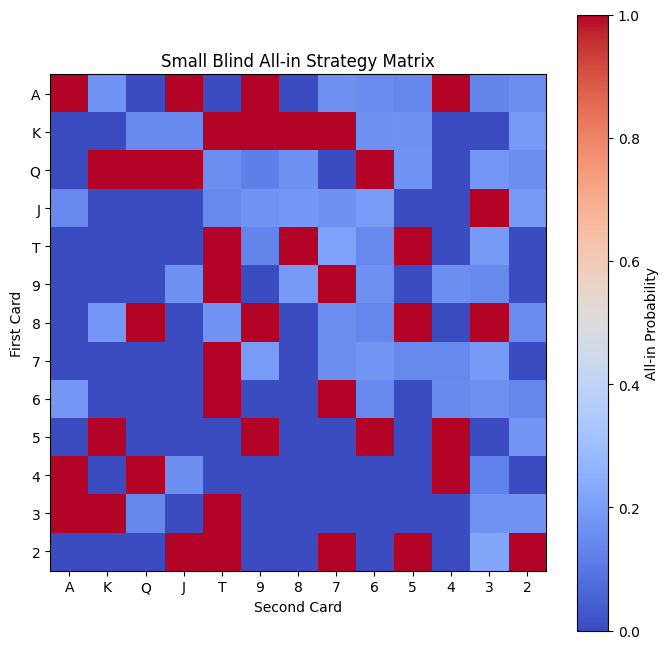

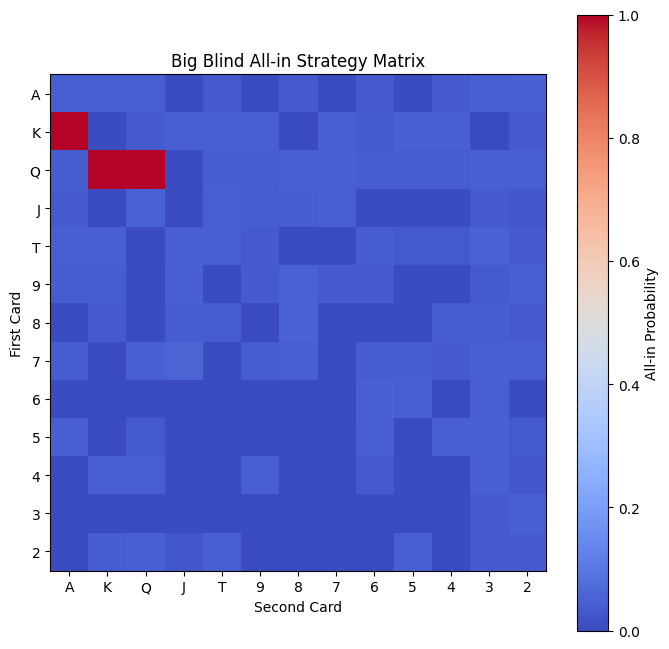

In [ ]:
# Result visualization
import matplotlib.pyplot as plt
# Example: Plotting the action matrix for Small Blind
smallBlind.to('cpu')
sb_strategy = torch.zeros((13,13))
for rank1 in range(13):
    for rank2 in range(13):
        one_hot_hand = torch.zeros(169, dtype=torch.float32)
        one_hot_hand[rank1*13+rank2] = 1
        with torch.no_grad():
            sb_strategy[rank1][rank2] = smallBlind(one_hot_hand).item()
            
# visualize the strategy matrix
# the top left is AA, top right is A2s, bottom left is A2o, bottom right is 22
# generate a correct figure with labels and color bar
# it should be 13x13 squares, with card labels on the top left of each square
# the frequency should be represented by color, where red means allin and blue means fold
plt.figure(figsize=(8, 8))
plt.imshow(sb_strategy, cmap='coolwarm', vmin=0, vmax=1)
plt.colorbar(label='All-in Probability')
plt.xticks(ticks=np.arange(13), labels=['A','K','Q','J','T','9','8','7','6','5','4','3','2'])
plt.yticks(ticks=np.arange(13), labels=['A','K','Q','J','T','9','8','7','6','5','4','3','2'])
plt.xlabel('Second Card')
plt.ylabel('First Card')
plt.title('Small Blind All-in Strategy Matrix')
plt.show()

# same for big blind
bigBlind.to('cpu')
bb_strategy = torch.zeros((13,13))
for rank1 in range(13):
    for rank2 in range(13):
        one_hot_hand = torch.zeros(169, dtype=torch.float32)
        one_hot_hand[rank1*13+rank2] = 1
        with torch.no_grad():
            bb_strategy[rank1][rank2] = bigBlind(one_hot_hand).item()

# visualize the strategy matrix
plt.figure(figsize=(8, 8))
plt.imshow(bb_strategy, cmap='coolwarm', vmin=0, vmax=1)
plt.colorbar(label='All-in Probability')
plt.xticks(ticks=np.arange(13), labels=['A','K','Q','J','T','9','8','7','6','5','4','3','2'])
plt.yticks(ticks=np.arange(13), labels=['A','K','Q','J','T','9','8','7','6','5','4','3','2'])
plt.xlabel('Second Card')
plt.ylabel('First Card')
plt.title('Big Blind All-in Strategy Matrix')
plt.show()